# Evaluating the Business Impact of AI-Powered Customer Support

## Business Question

Can AI-powered chatbots reduce customer support costs while maintaining customer satisfaction and service quality?

## Objectives

- Compare AI chatbots and human agents
- Analyze cost differences
- Analyze customer satisfaction differences
- Analyze response time differences
- Determine factors driving successful resolutions
- Build predictive models to identify high satisfaction interactions

##Business Problem
Does AI-powered customer support reduce operating costs while maintaining customer satisfaction and resolution quality?

##Data Overview & Preparation

In [2]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['axes.facecolor'] = 'f8f9fa'
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import os


In [3]:
data = pd.read_csv('/content/customer_service_interactions.csv')


#Inspect Data

data.info()
data.describe()
data.columns
data.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   interaction_id         10000 non-null  object 
 1   timestamp              10000 non-null  object 
 2   query_type             10000 non-null  object 
 3   handled_by             10000 non-null  object 
 4   response_time_min      10000 non-null  float64
 5   resolution_status      10000 non-null  object 
 6   customer_sentiment     10000 non-null  float64
 7   customer_satisfaction  10000 non-null  int64  
 8   interaction_cost_usd   10000 non-null  float64
 9   customer_id            10000 non-null  object 
 10  region                 10000 non-null  object 
 11  device_type            10000 non-null  object 
 12  follow_up_required     10000 non-null  bool   
dtypes: bool(1), float64(3), int64(1), object(8)
memory usage: 947.4+ KB


,0
interaction_id,0
timestamp,0
query_type,0
handled_by,0
response_time_min,0
resolution_status,0
customer_sentiment,0
customer_satisfaction,0
interaction_cost_usd,0
customer_id,0


##Exploratory Data Analysis




###This first section in the data analysis explores the distribution of the customer support work being handled.

In [4]:
#agent vs ai distribution

agent_counts = data['handled_by'].value_counts()
print(agent_counts)

print("\nPercentages:")
print(round(data['handled_by'].value_counts(normalize=True) * 100, 2))

handled_by
Human Agent    5049
AI Chatbot     4951
Name: count, dtype: int64

Percentages:
handled_by
Human Agent    50.49
AI Chatbot     49.51
Name: proportion, dtype: float64


In [5]:

# Convert timestamp to datetime (if it isn't already)
data['timestamp'] = pd.to_datetime(data['timestamp'])

# Create a date-only column
data['date'] = data['timestamp'].dt.date

#find the average number of interactions per day and see how much on average is being spent

# Total interactions
total_interactions = len(data)

# Number of unique days in dataset
total_days = data['date'].nunique()

# Average interactions per day
avg_interactions_per_day = total_interactions / total_days


print(f"Average Interactions Per Day: {avg_interactions_per_day:.2f}")

Average Interactions Per Day: 55.56


This dataset containes 10,000 customer service interactions. AI chatbots handled 4951 interactions (49%), while human agents handled 5049 interactions (~51%). This dataset is extremely balanced and will provide a suitable basis for comparing performance metrics between AI and human support channels.

###This next section in the data exploration analyzes cost distribution.

Total Cost in Six Months:

In [6]:
#total cost for six months

total_cost = data.groupby('handled_by')['interaction_cost_usd'].sum()
print("Total Cost for Six Month Period:")


total_human_cost = total_cost['Human Agent']
total_ai_cost = total_cost['AI Chatbot']
cost_diff = total_human_cost - total_ai_cost

print("\n")
print(f"Human Agent Cost: ${total_human_cost:,.2f}")
print(f"AI Chatbot Cost: ${total_ai_cost:,.2f}")
print("\n")
print(f"In just six months, human agents costed a total of ${cost_diff:,.2f} more than the AI chatbots")

Total Cost for Six Month Period:


Human Agent Cost: $35,329.80
AI Chatbot Cost: $14,891.75


In just six months, human agents costed a total of $20,438.05 more than the AI chatbots


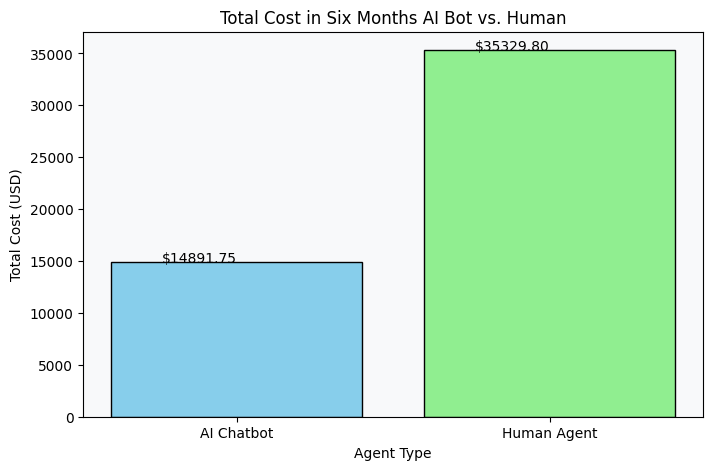

In [7]:
plt.figure(figsize=(8,5))

plt.bar(
    total_cost.index,
    total_cost.values,
    color=['skyblue', 'lightgreen'],
    edgecolor='black'
)

plt.title('Total Cost in Six Months AI Bot vs. Human')
plt.xlabel('Agent Type')
plt.ylabel('Total Cost (USD)')

for i, value in enumerate(total_cost.values):
    plt.text(i, value + 0.05, f'${value:.2f}', ha='right')

plt.show()

Over the entire six month period, human handled interactions generated $35,329.80 in support costs compared with $14,891.75 for AI handled interactions. Human support cost $20,438.05 more.

Average Daily Cost:

In [8]:
#total cost broken down by day

#create date column
data['timestamp'] = pd.to_datetime(data['timestamp'])
data['date'] = data['timestamp'].dt.date

# Calculate ACTUAL total daily cost by agent type
daily_cost = data.groupby(
    ['date', 'handled_by']
)['interaction_cost_usd'].sum().reset_index()

# Pivot so AI and Human become separate columns
daily_cost_pivot = daily_cost.pivot(
    index='date',
    columns='handled_by',
    values='interaction_cost_usd'
)

# Add TOTAL daily cost across both AI + Human
daily_cost_pivot['total_daily_cost'] = (
    daily_cost_pivot['Human Agent'] + daily_cost_pivot['AI Chatbot']
)

# Calculate daily cost difference
daily_cost_pivot['daily_cost_difference'] = (
    daily_cost_pivot['Human Agent'] - daily_cost_pivot['AI Chatbot']
)

print(daily_cost_pivot.head(10))

# daily average for each agent type
avg_daily_human_cost = daily_cost_pivot['Human Agent'].mean()
avg_daily_ai_cost = daily_cost_pivot['AI Chatbot'].mean()
avg_daily_total_cost = daily_cost_pivot['total_daily_cost'].mean()
avg_daily_cost_diff = avg_daily_human_cost - avg_daily_ai_cost

print("\n")
print(f"Daily Avg Human Agent Cost: ${avg_daily_human_cost:,.2f}")
print(f"Daily Avg AI Chatbot Cost: ${avg_daily_ai_cost:,.2f}")
print(f"Daily Avg Total Cost: ${avg_daily_total_cost:,.2f}")
print("\n")
print(f"Each day, human agents cost on average ${avg_daily_cost_diff:,.2f} more than AI chatbots")

handled_by  AI Chatbot  Human Agent  total_daily_cost  daily_cost_difference
date                                                                        
2024-01-01       62.48       173.66            236.14                 111.18
2024-01-02       68.45       124.78            193.23                  56.33
2024-01-03       62.11       200.82            262.93                 138.71
2024-01-04       94.13       226.92            321.05                 132.79
2024-01-05       57.64       156.12            213.76                  98.48
2024-01-06       93.05       213.34            306.39                 120.29
2024-01-07       62.84       212.82            275.66                 149.98
2024-01-08       70.73       221.49            292.22                 150.76
2024-01-09       58.66       147.70            206.36                  89.04
2024-01-10       63.87       196.98            260.85                 133.11


Daily Avg Human Agent Cost: $196.28
Daily Avg AI Chatbot Cost: $82.73
Dail

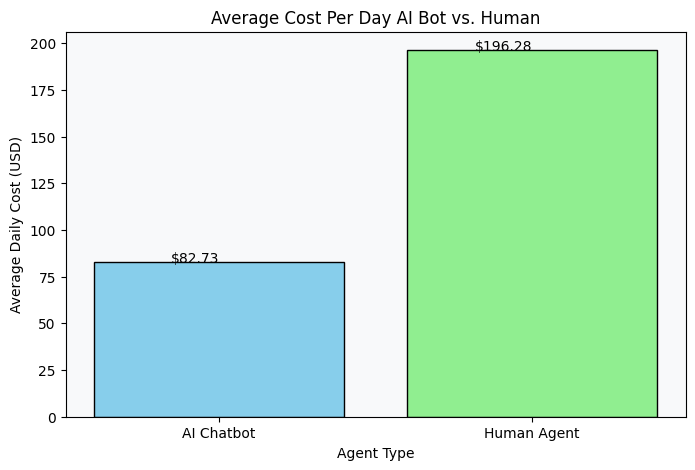

In [9]:
plt.figure(figsize=(8,5))

plt.bar(
    ['AI Chatbot', 'Human Agent'],
    [avg_daily_ai_cost, avg_daily_human_cost],
    color=['skyblue', 'lightgreen'],
    edgecolor='black'
)

plt.title('Average Cost Per Day AI Bot vs. Human')
plt.xlabel('Agent Type')
plt.ylabel('Average Daily Cost (USD)')

for i, value in enumerate([avg_daily_ai_cost, avg_daily_human_cost]):
    plt.text(
        i,
        value + 0.05,
        f'${value:,.2f}',
        ha='right'
    )

plt.show()

Human support cost on average $113.54 more than AI chatbots.

Cost Based Per Interaction:

In [10]:
#total cost broken down per interaction count

avg_cost_per_interaction = data.groupby('handled_by')['interaction_cost_usd'].mean()

avg_cost_per_interaction = (
    data.groupby('handled_by')['interaction_cost_usd']
      .mean()
      .sort_values())

avg_human_cost_per_interaction = avg_cost_per_interaction['Human Agent']
avg_ai_cost_per_interaction = avg_cost_per_interaction['AI Chatbot']


print(f"Each Human Agent interaction cost on average ${avg_human_cost_per_interaction:.2f}")
print(f"Each AI Agent interaction cost on average ${avg_ai_cost_per_interaction:.2f}")

print("\n")

savings_pct = ((avg_human_cost_per_interaction - avg_ai_cost_per_interaction) / avg_human_cost_per_interaction) * 100

Each Human Agent interaction cost on average $7.00
Each AI Agent interaction cost on average $3.01




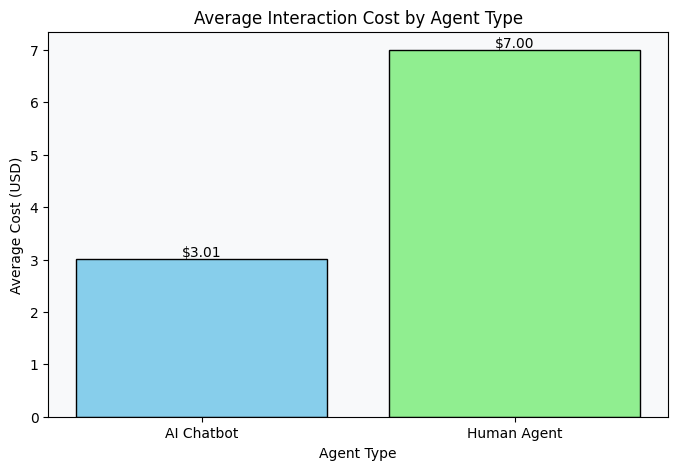

In [11]:
plt.figure(figsize=(8,5))

plt.bar(
    avg_cost_per_interaction.index,
    avg_cost_per_interaction.values,
    color=['skyblue', 'lightgreen'],
    edgecolor='black'
)

plt.title('Average Interaction Cost by Agent Type')
plt.xlabel('Agent Type')
plt.ylabel('Average Cost (USD)')

for i, value in enumerate(avg_cost_per_interaction.values):
    plt.text(i, value + 0.05, f'${value:.2f}', ha='center')

plt.show()

#is there a way to display that the avg number of interactions a day was 55?

At ticket level, each human interaction cost on average 7.00 USD, compared to the 3.01 USD fo AI. This means that AI lowers the average cost per interaction by 57.01%

In [12]:
# Current observed interaction mix
human_pct = (data['handled_by'] == 'Human Agent').mean()
ai_pct = (data['handled_by'] == 'AI Chatbot').mean()

# Baseline daily support cost using current mix
current_daily_cost = avg_interactions_per_day * (
    human_pct * avg_human_cost_per_interaction +
    ai_pct * avg_ai_cost_per_interaction
)

print(f"Current AI Share: {ai_pct:.1%}")
print(f"Current Human Share: {human_pct:.1%}")
print(f"Average Interactions per Day: {avg_interactions_per_day:.2f}")
print(f"Estimated Current Daily Support Cost: ${current_daily_cost:,.2f}")

Current AI Share: 49.5%
Current Human Share: 50.5%
Average Interactions per Day: 55.56
Estimated Current Daily Support Cost: $279.01


The dataset’s current support mix is approximately 50.5% human-handled interactions and 49.5% AI-handled interactions, with an average of 55.56 interactions per day. Using the average cost per interaction calculated in the previous section, the estimated daily support cost under the current operating model is $279.19 per day. This baseline is used to evaluate how support costs change as a larger share of interactions is shifted to AI.

# Scenario modelings / AI adoption scenarios
This section explores the financial analysis of AI implementation at different levels.

To estimate the financial impact of higher AI adoption, I modeled support cost using the observed average number of interactions per day and the average cost per interaction for each support type. This allows the interaction mix to be adjusted while holding daily support volume constant.

In [13]:
# AI adoption scenarios
adoption_rates = {
    'Current Model': ai_pct,
    '60% AI': 0.60,
    '75% AI': 0.75,
    '90% AI': 0.90
}

# Calculate daily cost for each adoption scenario
daily_cost_by_scenario = {}

for label, ai_share in adoption_rates.items():
    human_share = 1 - ai_share

    daily_cost_by_scenario[label] = avg_interactions_per_day * (
        human_share * avg_human_cost_per_interaction +
        ai_share * avg_ai_cost_per_interaction
    )

# Convert to 6-month and annual costs
six_month_cost_by_scenario = {
    label: cost * 180 for label, cost in daily_cost_by_scenario.items()
}

annual_cost_by_scenario = {
    label: cost * 365 for label, cost in daily_cost_by_scenario.items()
}

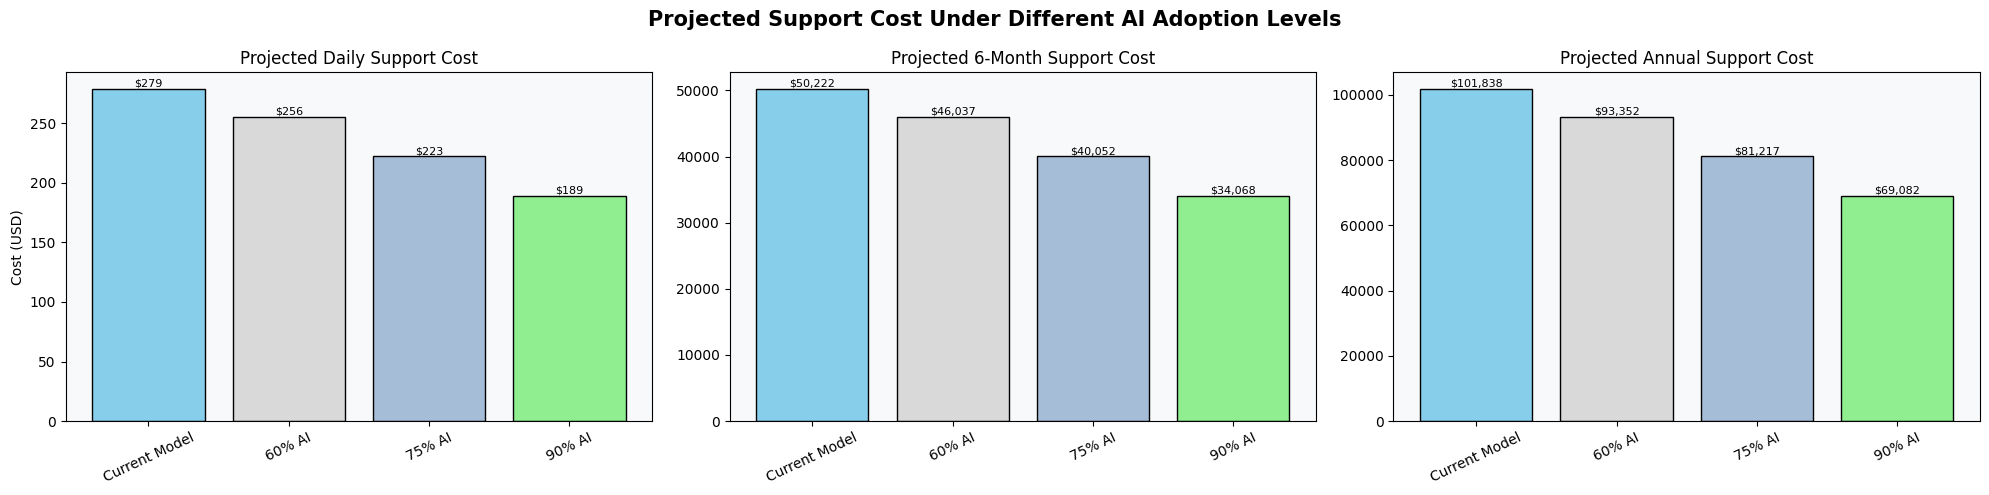

In [14]:
import matplotlib.pyplot as plt

labels = list(adoption_rates.keys())

daily_costs = [daily_cost_by_scenario[label] for label in labels]
six_month_costs = [six_month_cost_by_scenario[label] for label in labels]
annual_costs = [annual_cost_by_scenario[label] for label in labels]

colors = ['skyblue', '#D9D9D9', '#A6BDD7', 'lightgreen']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Daily
axes[0].bar(labels, daily_costs, color=colors, edgecolor='black')
axes[0].set_title('Projected Daily Support Cost')
axes[0].set_ylabel('Cost (USD)')
axes[0].tick_params(axis='x', rotation=25)

for i, value in enumerate(daily_costs):
    axes[0].text(i, value, f'${value:,.0f}', ha='center', va='bottom', fontsize=8)

# 6-Month
axes[1].bar(labels, six_month_costs, color=colors, edgecolor='black')
axes[1].set_title('Projected 6-Month Support Cost')
axes[1].tick_params(axis='x', rotation=25)

for i, value in enumerate(six_month_costs):
    axes[1].text(i, value, f'${value:,.0f}', ha='center', va='bottom', fontsize=8)

# Annual
axes[2].bar(labels, annual_costs, color=colors, edgecolor='black')
axes[2].set_title('Projected Annual Support Cost')
axes[2].tick_params(axis='x', rotation=25)

for i, value in enumerate(annual_costs):
    axes[2].text(i, value, f'${value:,.0f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(
    'Projected Support Cost Under Different AI Adoption Levels',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [15]:
# SAVINGS

baseline_cost = daily_cost_by_scenario['Current Model']

periods = ['Daily', '6 Months', 'Annual']
savings_by_adoption = {}

print("Projected Savings Compared to Current Model:")
print()

for label in ['60% AI', '75% AI', '90% AI']:
    daily_savings = baseline_cost - daily_cost_by_scenario[label]
    six_month_savings = daily_savings * 180
    annual_savings = daily_savings * 365

    savings_by_adoption[label] = [
        daily_savings,
        six_month_savings,
        annual_savings
    ]

    print(f"{label} Adoption:")
    print(f"Daily Savings: ${daily_savings:,.2f}")
    print(f"6-Month Savings: ${six_month_savings:,.2f}")
    print(f"Annual Savings: ${annual_savings:,.2f}")
    print()

Projected Savings Compared to Current Model:

60% AI Adoption:
Daily Savings: $23.25
6-Month Savings: $4,185.05
Annual Savings: $8,486.35

75% AI Adoption:
Daily Savings: $56.50
6-Month Savings: $10,169.39
Annual Savings: $20,621.25

90% AI Adoption:
Daily Savings: $89.74
6-Month Savings: $16,153.72
Annual Savings: $32,756.16



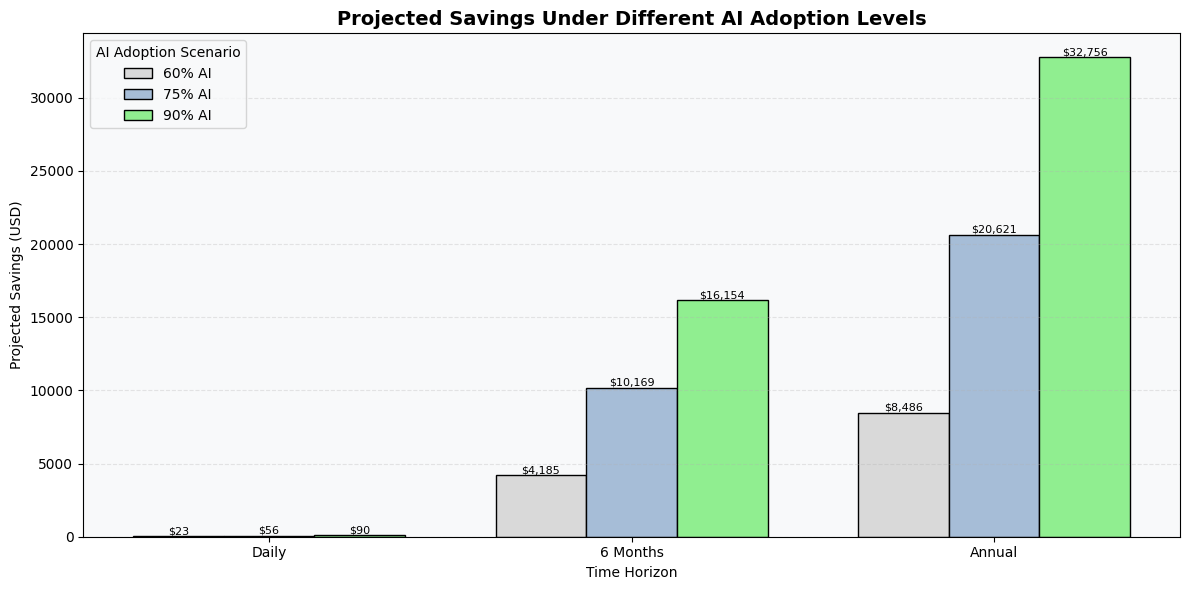

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# remove current model from savings chart
filtered_savings = {
    label: savings
    for label, savings in savings_by_adoption.items()
    if label != 'Current Model'
}

x = np.arange(len(periods))
width = 0.25

plt.figure(figsize=(12,6))

colors = ['#D9D9D9', '#A6BDD7', 'lightgreen']
offsets = [-width, 0, width]

for (label, savings), color, offset in zip(filtered_savings.items(), colors, offsets):
    bars = plt.bar(
        x + offset,
        savings,
        width,
        label=label,
        color=color,
        edgecolor='black'
    )

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'${height:,.0f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.xticks(x, periods)

plt.title(
    'Projected Savings Under Different AI Adoption Levels',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Time Horizon')
plt.ylabel('Projected Savings (USD)')

plt.legend(
    title='AI Adoption Scenario',
    loc='upper left'
)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#Service Quality and Customer Experience
This section explores whether utilizing AI chatbots over Humans hurt service quality using the actual data provided.

**Issue Resolution rate**

Are AI handled issues resolved at a similiar rate to human-handled issues?

In [17]:
#Calculate the percentage breakdwon

resolution_pct = pd.crosstab(
    data['handled_by'],
    data['resolution_status'],
    normalize='index'
) * 100

print(resolution_pct.round(2))

resolution_status  Escalated  Pending  Resolved
handled_by                                     
AI Chatbot             20.00     9.43     70.57
Human Agent            15.92     5.11     78.97


In [18]:
# Pull resolved rate only

resolved_rate = (
    data.groupby('handled_by')['resolution_status']
      .apply(lambda x: (x == 'Resolved').mean() * 100)
)

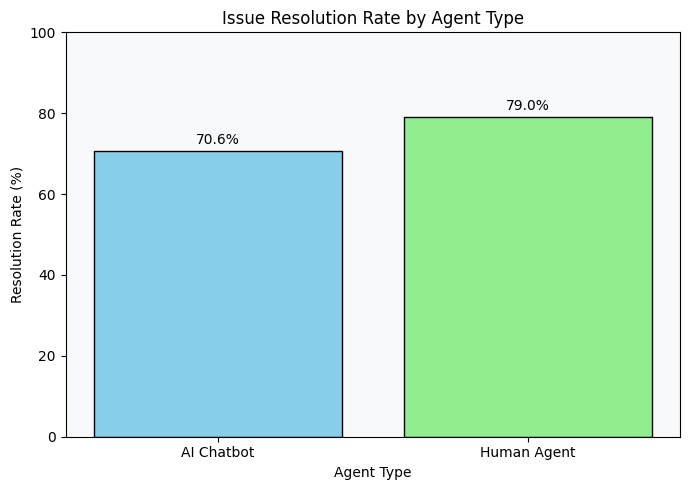

In [19]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    resolved_rate.index,
    resolved_rate.values,
    color=['skyblue', 'lightgreen'],
    edgecolor='black'
)

plt.title('Issue Resolution Rate by Agent Type')
plt.xlabel('Agent Type')
plt.ylabel('Resolution Rate (%)')
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

To evaluate whether AI support can resolve customer issues as effectively as human agents, I compared the share of interactions marked as resolved for each support type. The results show that Human agent achieved a resolution rate of 79% compared with 70.6% for AI, suggesting that AI support slightly underperformed on issue resolution.

**Customer Satisfaction**

Do customers report similiar satisfaction when served by AI versus human agents?

In [20]:
avg_satisfaction = data.groupby('handled_by')['customer_satisfaction'].mean()

print("Average Satisfaction Rating out of 5:")
print('\n')
print(avg_satisfaction)

Average Satisfaction Rating out of 5:


handled_by
AI Chatbot     3.312866
Human Agent    3.260250
Name: customer_satisfaction, dtype: float64


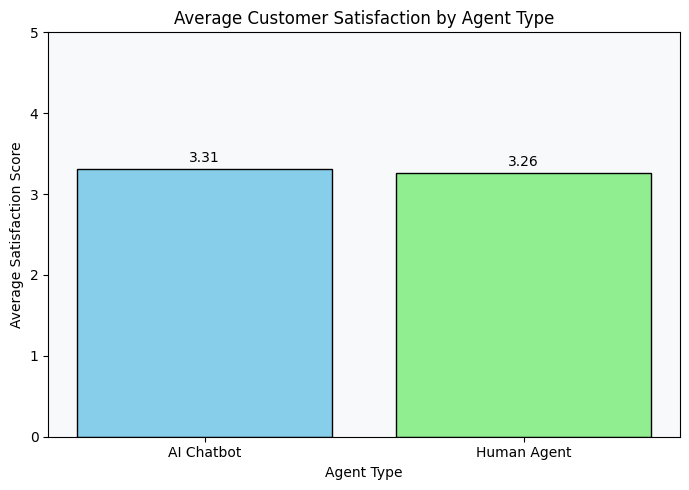

In [21]:
avg_satisfaction = data.groupby('handled_by')['customer_satisfaction'].mean()

plt.figure(figsize=(7,5))

bars = plt.bar(
    avg_satisfaction.index,
    avg_satisfaction.values,
    color=['skyblue', 'lightgreen'],
    edgecolor='black'
)

plt.title('Average Customer Satisfaction by Agent Type')
plt.xlabel('Agent Type')
plt.ylabel('Average Satisfaction Score')
plt.ylim(0, 5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [22]:
satisfaction_dist = pd.crosstab(
    data['handled_by'],
    data['customer_satisfaction'],
    normalize='index'
) * 100

print("Satisfaction Distribution by Agent Type:")
print('\n')
print(satisfaction_dist.round(2))

Satisfaction Distribution by Agent Type:


customer_satisfaction     1      2      3      4      5
handled_by                                             
AI Chatbot             6.30  14.22  32.84  35.16  11.47
Human Agent            4.34  15.07  39.49  32.42   8.67


Customer satisfaction scores were very similar across support types, with AI chatbot interactions averaging 3.31 compared with 3.26 for human agents. While both distributions were centered around mid-range ratings, AI interactions showed a slightly higher share of 4- and 5-star responses. This suggests that, in this dataset, AI support maintained customer satisfaction at a level comparable to human agents.

**Response time**

Do AI chatbots deliver a resolution at a quicker speed than human agents?

In [23]:
#Calculate avg response time

avg_response = data.groupby('handled_by')['response_time_min'].mean()

print("Average Response Time by Agent Type:")
print('\n')
print(avg_response)

Average Response Time by Agent Type:


handled_by
AI Chatbot     1.506227
Human Agent    7.045356
Name: response_time_min, dtype: float64


In [24]:
print("\nSummary Statistics of Response Times:")
print('\n')
print(data.groupby('handled_by')['response_time_min'].describe())


Summary Statistics of Response Times:


              count      mean       std  min   25%   50%   75%    max
handled_by                                                           
AI Chatbot   4951.0  1.506227  0.660884  0.2  1.04  1.49  1.97   4.02
Human Agent  5049.0  7.045356  2.897789  0.5  5.07  7.04  8.98  17.15


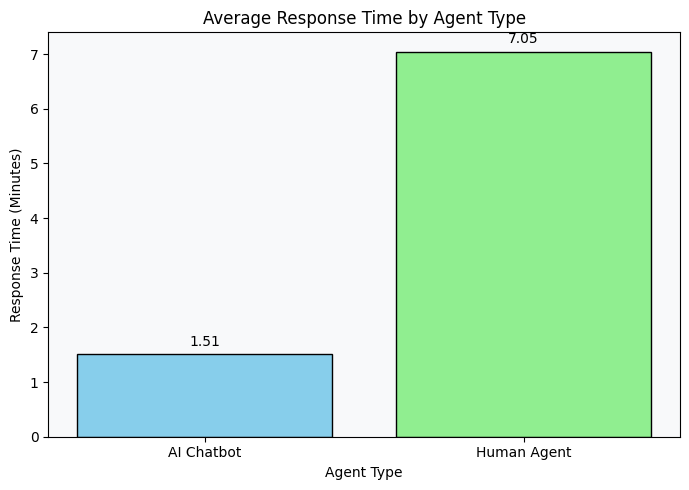

In [25]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    avg_response.index,
    avg_response.values,
    color=['skyblue', 'lightgreen'],
    edgecolor='black'
)

plt.title('Average Response Time by Agent Type')
plt.xlabel('Agent Type')
plt.ylabel('Response Time (Minutes)')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [26]:
human_response_time = avg_response['Human Agent']
ai_response_time = avg_response['AI Chatbot']

response_reduction_pct = (
    (human_response_time - ai_response_time) / human_response_time
) * 100

print(f"Human Agent average response time: {human_response_time:.2f} minutes")
print(f"AI Chatbot average response time: {ai_response_time:.2f} minutes")
print('\n')
print(f"AI reduces average response time by {response_reduction_pct:.2f}%")

Human Agent average response time: 7.05 minutes
AI Chatbot average response time: 1.51 minutes


AI reduces average response time by 78.62%


Response time was one of the clearest operational differences between support types. AI chatbot interactions averaged 1.51 minutes compared with 7.05 minutes for human agents, meaning AI reduced average response time by approximately 78.6%. This suggests that AI support delivers substantially faster responses, which may help explain why customer satisfaction remained comparable despite the lower cost structure.

**Customer Sentiment**

Do customers leave the interaction with a more positive or negative tone depending what agent type they were helped by?

In [27]:
#Create Sentiment Categories

bins = [-1, -0.60, -0.2, 0.2, 0.6, 1]

labels = [
    'Negative',
    'Slight Neg',
    'Neutral',
    'Slight Pos',
    'Positive'
]

data['sentiment_category'] = pd.cut(
    data['customer_sentiment'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [28]:
sentiment_counts = data['sentiment_category'].value_counts().sort_index()
sentiment_counts

,count
sentiment_category,
Negative,13
Slight Neg,322
Neutral,2780
Slight Pos,4863
Positive,2022


In [29]:
#Compare percentage of each sentiment category by agent type

sentiment_pct = pd.crosstab(
    data['handled_by'],
    data['sentiment_category'],
    normalize='index'
) * 100

sentiment_pct = sentiment_pct.round(2)
sentiment_pct

sentiment_category,Negative,Slight Neg,Neutral,Slight Pos,Positive
handled_by,,,,,
AI Chatbot,0.18,4.56,32.66,47.14,15.45
Human Agent,0.08,1.90,23.03,50.09,24.90


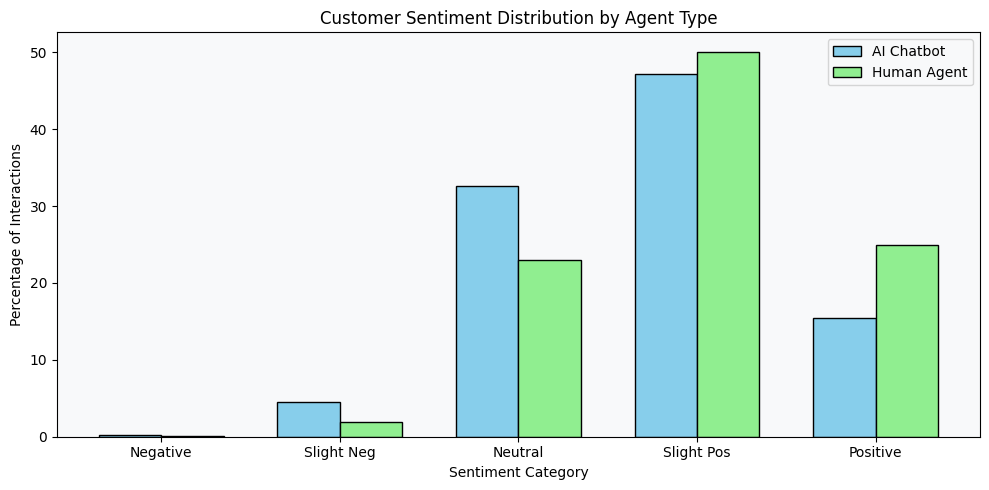

In [30]:
import numpy as np
import matplotlib.pyplot as plt

categories = sentiment_pct.columns
x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(
    x - width/2,
    sentiment_pct.loc['AI Chatbot'],
    width,
    label='AI Chatbot',
    color='skyblue',
    edgecolor='black'
)

plt.bar(
    x + width/2,
    sentiment_pct.loc['Human Agent'],
    width,
    label='Human Agent',
    color='lightgreen',
    edgecolor='black'
)

plt.xticks(x, categories)
plt.ylabel('Percentage of Interactions')
plt.xlabel('Sentiment Category')
plt.title('Customer Sentiment Distribution by Agent Type')
plt.legend()

plt.tight_layout()
plt.show()

In [31]:
avg_sentiment = data.groupby('handled_by')['customer_sentiment'].mean()
avg_sentiment

,customer_sentiment
handled_by,
AI Chatbot,0.299073
Human Agent,0.400456


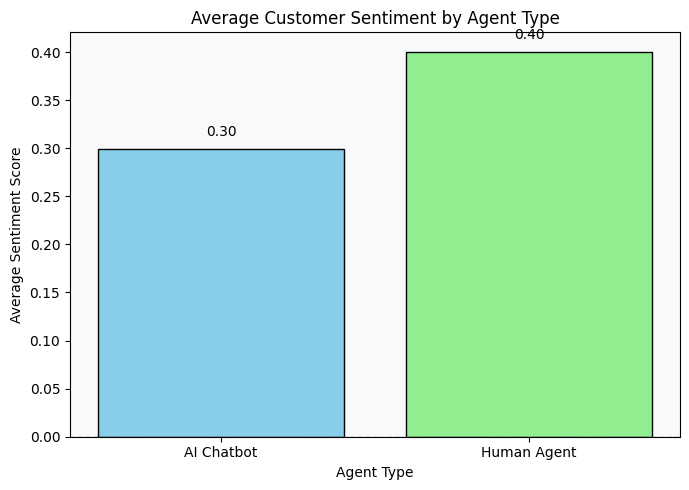

In [32]:
avg_sentiment = data.groupby('handled_by')['customer_sentiment'].mean()

plt.figure(figsize=(7,5))

plt.bar(
    avg_sentiment.index,
    avg_sentiment.values,
    color=['skyblue', 'lightgreen'],
    edgecolor='black'
)

plt.title('Average Customer Sentiment by Agent Type')
plt.xlabel('Agent Type')
plt.ylabel('Average Sentiment Score')

for i, value in enumerate(avg_sentiment.values):
    plt.text(
        i,
        value + 0.01,
        f'{value:.2f}',
        ha='center',
        va='bottom'
    )

plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

Customer sentiment was positive overall for both support types, with average sentiment scores of 0.30 for AI chatbot interactions and 0.40 for human-handled interactions. While the difference is not extreme, the results suggest that human support may still generate slightly more positive customer experiences on average.

##Statistical Testing

While the exploratory analysis identified differences between AI chatbot and human agent interactions, statistical hypothesis testing was performed to determine whether these differences are statistically significant or simply due to random variation in the data.

An independent two-sample Welch's t-test was conducted for each key performance metric because the analysis compares the mean of a continuous variable between two independent groups (AI Chatbot and Human Agent). A significance level (α) of 0.05 was used for all tests.

#### **Customer Satisfaction**

The first analysis examines whether average customer satisfaction differs between AI chatbot interactions and human agent interactions.

**Hypotheses:**

Null Hypothesis (H₀):
The mean customer satisfaction rating is the same for AI chatbot and human agent interactions.

Alternative Hypothesis (H₁):
The mean customer satisfaction rating differs between AI chatbot and human agent interactions.

In [33]:
from scipy.stats import ttest_ind

human_satisfaction = data[data['handled_by'] == 'Human Agent']['customer_satisfaction']
ai_satisfaction = data[data['handled_by'] == 'AI Chatbot']['customer_satisfaction']

t_stat, p_value = ttest_ind(
    human_satisfaction,
    ai_satisfaction,
    equal_var=False
)

print(f"Human Mean Satisfaction Rating: {human_satisfaction.mean():.2f}")
print(f"AI Mean Satisfaction Rating: {ai_satisfaction.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")

if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {p_value:.4f}")

Human Mean Satisfaction Rating: 3.26
AI Mean Satisfaction Rating: 3.31
T-statistic: -2.6068
P-value: 0.0092


####**Interaction Cost**
This analysis evaluates whether the average cost per customer interaction differs between AI chatbot and human agent interactions.

**Hypotheses:**

Null Hypothesis (H₀):
The mean interaction cost is the same for AI chatbot and human agent interactions.

Alternative Hypothesis (H₁):
The mean interaction cost differs between AI chatbot and human agent interactions.

In [34]:
from scipy.stats import ttest_ind

human_cost = data[data['handled_by'] == 'Human Agent']['interaction_cost_usd']
ai_cost = data[data['handled_by'] == 'AI Chatbot']['interaction_cost_usd']

t_stat, p_value = ttest_ind(
    human_cost,
    ai_cost,
    equal_var=False
)

print(f"Human Agent Mean Cost: ${human_cost.mean():.2f}")
print(f"AI Chatbot Mean Cost: ${ai_cost.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")

if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {p_value:.4f}")

Human Agent Mean Cost: $7.00
AI Chatbot Mean Cost: $3.01
T-statistic: 131.6440
P-value: < 0.001


####**Response Time**
This analysis examines whether average response time differs between AI chatbot and human agent interactions.

**Hypothesis**:

Null Hypothesis (H₀):
The mean response time is the same for AI chatbot and human agent interactions.

Alternative Hypothesis (H₁):
The mean response time differs between AI chatbot and human agent interactions.

In [35]:
from scipy.stats import ttest_ind

human_response_time = data[data['handled_by'] == 'Human Agent']['response_time_min']
ai_response_time = data[data['handled_by'] == 'AI Chatbot']['response_time_min']

t_stat, p_value = ttest_ind(
    human_response_time,
    ai_response_time,
    equal_var=False
)

print(f"Human Agent Mean Response Time: {human_response_time.mean():.4f}")
print(f"AI Chatbot Mean Response Time: {ai_response_time.mean():.4f}")
print(f"T-statistic: {t_stat:.4f}")


if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {p_value:.4f}")

Human Agent Mean Response Time: 7.0454
AI Chatbot Mean Response Time: 1.5062
T-statistic: 132.3592
P-value: < 0.001


####**Customer Sentiment**

This analysis evaluates whether average customer sentiment differs between AI chatbot and human agent interactions.

**Hypothesis:**

Null Hypothesis (H₀):
The mean customer sentiment score is the same for AI chatbot and human agent interactions.

Alternative Hypothesis (H₁):
The mean customer sentiment score differs between AI chatbot and human agent interactions.

In [36]:
from scipy.stats import ttest_ind

human_sentiment = data[data['handled_by'] == 'Human Agent']['customer_sentiment']
ai_sentiment = data[data['handled_by'] == 'AI Chatbot']['customer_sentiment']

t_stat, p_value = ttest_ind(
    human_sentiment,
    ai_sentiment,
    equal_var=False
)

print(f"Human Agent Mean Sentiment: {human_sentiment.mean():.4f}")
print(f"AI Chatbot Mean Sentiment: {ai_sentiment.mean():.4f}")
print(f"T-statistic: {t_stat:.4f}")

if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print(f"P-value: {p_value:.4f}")

Human Agent Mean Sentiment: 0.4005
AI Chatbot Mean Sentiment: 0.2991
T-statistic: 17.3443
P-value: < 0.001


####**Results & Interpretation:**

In [37]:
import pandas as pd

statistical_results = pd.DataFrame({
    "Metric": [
        "Customer Satisfaction",
        "Interaction Cost",
        "Response Time",
        "Customer Sentiment"
    ],
    "Human Mean": [
        3.23,
        7.00,
        7.05,
        0.400
    ],
    "AI Mean": [
        3.31,
        3.01,
        1.50,
        0.299
    ],
    "T-statistic": [
        -2.60,
        131.64,
        132.35,
        17.34
    ],
    "P-value": [
        "0.009",
        "< 0.001",
        "< 0.001",
        "< 0.001"
    ],
    "Significant?": [
        "Yes",
        "Yes",
        "Yes",
        "Yes"
    ]
})

statistical_results

,Metric,Human Mean,AI Mean,T-statistic,P-value,Significant?
0,Customer Satisfaction,3.23,3.310,-2.60,0.009,Yes
1,Interaction Cost,7.00,3.010,131.64,< 0.001,Yes
2,Response Time,7.05,1.500,132.35,< 0.001,Yes
3,Customer Sentiment,0.40,0.299,17.34,< 0.001,Yes


The independent Welch's t-tests found statistically significant differences across all four performance metrics.

- **Customer Satisfaction:** A statistically significant difference was found between AI chatbot and human agent interactions (*t* = -2.60, *p* = 0.009). Therefore, the null hypothesis was rejected.

- **Interaction Cost:** A statistically significant difference was found between AI chatbot and human agent interactions (*t* = 131.64, *p* < 0.001). Therefore, the null hypothesis was rejected.

- **Response Time:** A statistically significant difference was found between AI chatbot and human agent interactions (*t* = 132.35, *p* < 0.001). Therefore, the null hypothesis was rejected.

- **Customer Sentiment:** A statistically significant difference was found between AI chatbot and human agent interactions (*t* = 17.34, *p* < 0.001). Therefore, the null hypothesis was rejected.

Overall, the hypothesis tests provide statistical evidence that the observed differences between AI chatbot and human agent interactions are unlikely to be due to random variation. These findings validate the patterns identified during the exploratory data analysis and strengthen the conclusion that AI chatbots and human agents differ significantly across key customer support performance metrics.

##Machine Learning

While the previous sections explored historical trends through exploratory data analysis and statistical testing, this section demonstrates how machine learning can be used to support future customer service decisions. Two supervised classification models were developed to illustrate practical business applications of predictive analytics:

- Predict whether a customer interaction will require follow-up.
- Predict whether an interaction is more appropriate for an AI chatbot or a human agent.

#### **Model 1: Predicting Follow-Up Required**

Business Question: Can we predict whether a customer interaction will require additional follow-up?

This type of prediction can help organizations proactively identify interactions that may need additional attention, allowing support teams to allocate resources more effectively and improve customer service outcomes.

Prepare Data:

In [69]:
# Features
X = data[['handled_by',
          'query_type',
          'response_time_min',
          'customer_satisfaction',
          'customer_sentiment',
          'region',
          'device_type']]

# Target
y = data['follow_up_required']


#Encode Categories

X = X.copy()

encoder = LabelEncoder()

categorical_columns = [
    'handled_by',
    'query_type',
    'region',
    'device_type'
]

for col in categorical_columns:
    X[col] = encoder.fit_transform(X[col])

y = encoder.fit_transform(y)

Train/Test Split & Train Model:

In [70]:
#Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


#Train Model

rf_followup = RandomForestClassifier(
    random_state=42
)

rf_followup.fit(X_train, y_train)

#Make Prediction

y_pred = rf_followup.predict(X_test)

Model Evaluation:

In [71]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()

print(classification_report(y_test, y_pred))

Accuracy: 0.81

              precision    recall  f1-score   support

           0       0.82      0.99      0.89      1630
           1       0.22      0.01      0.02       370

    accuracy                           0.81      2000
   macro avg       0.52      0.50      0.46      2000
weighted avg       0.71      0.81      0.73      2000



Confusion Matrix:

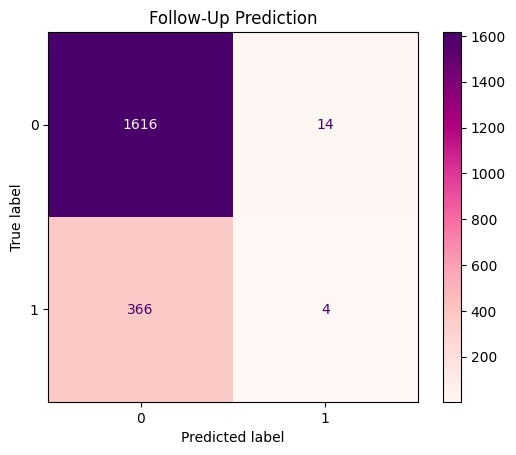

In [72]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='RdPu'
)

plt.title("Follow-Up Prediction")
plt.show()

Feature Importance:

In [73]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_followup.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
2,response_time_min,0.301296
4,customer_sentiment,0.270031
5,region,0.223317
1,query_type,0.081022
3,customer_satisfaction,0.068362
6,device_type,0.041188
0,handled_by,0.014785


### Results & Interpretation

The Random Forest classifier achieved an overall accuracy of **81.0%** when predicting whether a customer interaction would require additional follow-up. The model was developed using information that would reasonably be available during or immediately after an interaction, excluding interaction cost.

The confusion matrix shows that the model correctly classified **1,616** interactions that did not require follow-up and correctly identified **4** interactions that did require follow-up. Although the overall accuracy appears high, the model correctly detected only **1.1%** of the interactions that actually required follow-up, indicating very low recall for the minority class.

These results suggest that the available predictor variables do not provide enough information to reliably identify interactions requiring additional support. The dataset is also highly imbalanced, with substantially more interactions that did not require follow-up than interactions that did. As a result, the model favored the majority class, producing high overall accuracy but limited practical value for identifying customers who need additional assistance.

Overall, the model demonstrates the potential application of machine learning for predicting customer follow-up needs. However, additional predictive variables or techniques for handling class imbalance would likely be required to improve performance and make the model suitable for operational use.

#### Model Limitations

The follow-up prediction dataset is highly imbalanced, with only **370** of the **2,000** test observations requiring follow-up. Because most interactions did not require additional support, the Random Forest classifier favored predicting the majority class. Future improvements could include collecting additional predictive variables, applying class weighting, or using oversampling techniques to improve the model's ability to identify follow-up cases.

####**Model 2: Intelligent Interaction Routing**

Business Question: Based on the characteristics of an incoming interaction, can we predict whether it should be routed to an AI chatbot or a human agent?

This type of predictive model could support intelligent routing systems by recommending the most appropriate support channel before an interaction begins.

Prepare Data:

In [74]:
#Features

X = data[['query_type',
          'region',
          'device_type',
          'customer_sentiment']]

#Target

y = data['handled_by']

#Encode Categories

X = X.copy()

encoder = LabelEncoder()

categorical_columns = [
    'query_type',
    'region',
    'device_type',
    'customer_sentiment'

]

for col in categorical_columns:
    X[col] = encoder.fit_transform(X[col])

y = encoder.fit_transform(y)

Train/Test Split & Train Model:

In [75]:
#Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

#Random Forest Model

rf_route = RandomForestClassifier(
    random_state=42
)

rf_route.fit(X_train, y_train)

#Make Predictions

y_pred = rf_route.predict(X_test)


Evaluate Model:

In [76]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.522
              precision    recall  f1-score   support

           0       0.51      0.49      0.50       976
           1       0.53      0.55      0.54      1024

    accuracy                           0.52      2000
   macro avg       0.52      0.52      0.52      2000
weighted avg       0.52      0.52      0.52      2000



Confusion Matrix:

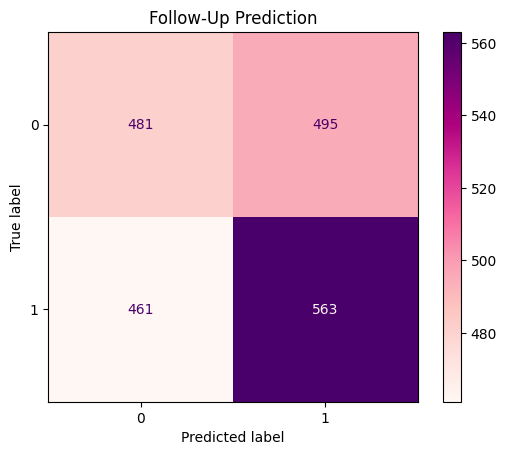

In [78]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='RdPu'
)

plt.title("Follow-Up Prediction")
plt.show()

Feature Importance:

In [77]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_route.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
3,customer_sentiment,0.447458
1,region,0.367915
0,query_type,0.116213
2,device_type,0.068413


### Results & Interpretation

The Random Forest classifier achieved an overall accuracy of **52.2%** when predicting whether a customer interaction should be handled by an AI chatbot or a human agent. Using query type, customer sentiment, region, and device type as predictor variables, the model produced balanced precision, recall, and F1-scores for both classes.

The confusion matrix shows that the model correctly classified **481** human agent interactions and **563** AI chatbot interactions. However, with an overall accuracy of **52.2%**, the model performed only slightly better than random guessing.

Overall, the results indicate that the current model is not able to reliably distinguish whether an interaction should be routed to an AI chatbot or a human agent using the available predictor variables. While the model demonstrates a practical application of machine learning for intelligent interaction routing, its predictive performance suggests that additional information would be needed before such a model could be used in a real-world customer support environment.

#### Model Limitations

The routing model was developed using only information that would realistically be available before a customer interaction begins, including query type, customer sentiment, region, and device type. Although these variables are useful descriptors of an interaction, they do not capture many of the factors that influence routing decisions in practice.

Additional information such as issue complexity, customer account history, previous interactions, message content, urgency, or business-specific routing rules would likely improve predictive performance. Incorporating these variables, along with additional model tuning or feature engineering, may produce a more accurate and reliable intelligent routing model.

# Business Impact & Recommendations

This analysis demonstrates that AI chatbots can improve operational efficiency while maintaining comparable customer satisfaction. Statistical testing confirmed that AI chatbot interactions were significantly faster and less expensive than human agent interactions, while customer sentiment remained stronger for human agent interactions.

The AI adoption scenarios further suggest that increasing chatbot usage can generate meaningful cost savings, particularly for organizations managing a high volume of customer interactions. These findings indicate that AI chatbots are well suited for routine, repetitive, and lower-complexity customer inquiries.

However, the machine learning analysis also showed that routing customer interactions based solely on limited customer and interaction characteristics is difficult. This suggests that organizations should continue using business rules and human oversight when determining whether an interaction should be handled by an AI chatbot or a human agent.

## Recommendations

- Continue expanding AI chatbot usage for routine and high-volume customer inquiries.
- Maintain human agents for complex, sensitive, or emotionally driven interactions.
- Use AI as a complement to human agents rather than a complete replacement.
- Collect additional customer and interaction data to improve future predictive routing models.
- Continue monitoring customer satisfaction and sentiment to ensure operational efficiency does not negatively impact the customer experience.

#**Bottom Line:**

 AI chatbots offer significant operational and financial benefits for routine customer support, but a hybrid model that combines AI efficiency with human expertise provides the most balanced approach to customer service.